# GUV Image Analysis Pipeline

This notebook contains a pipeline for analyzing GUV (Giant Unilamellar Vesicle) images. It single-frame data from .tif files.
For movie-style analysis, we apply the same tools but in a more autometed format, saving more intermediate material

Jacob Kers, 2024

## Imports and Setup

In [55]:
import csv
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from openpyxl import load_workbook
import numpy as np
from skimage import io
from skimage import measure
#customs:
import guv_binary_ops
import guv_tools



## Giant Unilamellar Vesicle or GUV
Our basic 'info unit' is a single GUV, we note it as ROI (region-of-interest).  We keep track of where it came from via a simple excel table, easily readable for both user and Python. The 'GUV' class closely follows the header in the Excel table. Here, we index per movie, then per ROI. For a single GUV or ROI, we define a 'GUV object'.


In [3]:
class GUV:
    def __init__(self):
        self.pathname = 0
        self.filename = 0
        self.exp_id = 0
        self.movie_id = 0
        self.guv_id = 0
        self.use_it = 0
        self.notes = 'any note'

# Collect info
read GUV info from an Excel file and returns a list of GUV objects for a specific run ID.
We define a `GUV` class to store properties of a single GUV movie.

In [26]:
# Example usage
if 1: 
    excelpath=str("D:/jkerssemakers/Dropbox/CD_recent/BN_CD24_Bert/")
    excelname =str("Bert_data_overview.xlsx")
wb = load_workbook(excelpath+excelname)
sheet_files = wb['guvs']
# Create a dictionary of column names:
Header = {COL[0].value: idx for idx, COL in enumerate(sheet_files.iter_cols(1, sheet_files.max_column))}
#pick one particular experiment (or more):
exp_id=1

#build a list of 'GUV' objects:
Guv_list = []
for row_cells in sheet_files.iter_rows(min_row=2, max_row=sheet_files.max_row):
    Guv = GUV()
    Guv.pathname = row_cells[Header["pathname"]].value
    Guv.filename = row_cells[Header["filename"]].value
    Guv.exp_id = row_cells[Header["exp_id"]].value
    Guv.movie_id = row_cells[Header["movie_id"]].value
    Guv.label = row_cells[Header["guv_id"]].value
    Guv.use_it = row_cells[Header["use_it"]].value
    Guv.crop_it = row_cells[Header["notes"]].value
    if Guv.exp_id == exp_id:
        Guv_list.append(Guv)
        print(Guv.filename)



1mM_cholDNA_647dna_overnight_1028.tif
1mM_cholDNA_647dna_overnight_1029.tif
1mM_cholDNA_647dna_overnight_1030.tif


## Main Analysis Pipeline
pick a GUV and show its color channels and the 'work image', which is just the sum of these channels:


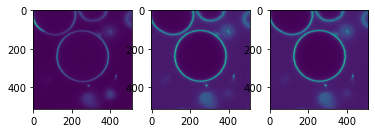

In [33]:
Guv = Guv_list[0]
image_path = Guv.pathname + '\\' + Guv.filename
roi = np.array(io.imread(image_path))
# extract other basic metadata
clrs, rr,cc,=np.shape(roi)
fig, axs = plt.subplots(1, clrs +1)
#setup a work image for edge detection etc
for color_i, chan in enumerate(roi):
    if color_i==0: 
        roi_work=chan-np.min(chan)
    else:
            roi_work=+ chan - np.min(chan)
    axs[color_i].imshow(chan) 
axs[color_i+1].imshow(roi_work)
plt.show()              

# Isolating a GUV

We perform a series of binary operations to isolate the single GUV-of-interest. Once this is done, we get a first set of measurement parameters from the binarized, filled-up overall shape. These parameters (such as center-of-mass position) can later be used for more refined processing such as radial edge detection

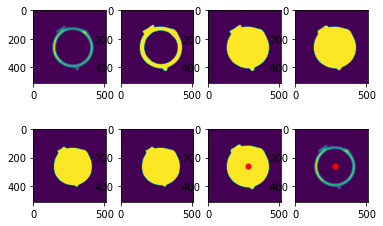

In [84]:


if np.max(np.array(roi_work))>0:
    roi_work=guv_tools.soft_mask_it(roi_work)
    roi_work=guv_tools.smooth_it(roi_work,labda=2)
    roi_work= roi_work.astype(int)
    #transfer to binary operations to gat masks and robust coordinates
    fgm0=guv_binary_ops.sorted_pixels_treshold(roi_work)[1]
    fgm1 = guv_binary_ops.binary_fill_holes(fgm0, guv_binary_ops.disk(3))
    fgm2 = guv_binary_ops.binary_opening(fgm1, guv_binary_ops.disk(3), iterations = 6)
    fgm3 = guv_binary_ops.binary_erosion(fgm2, guv_binary_ops.disk(3), iterations = 5)
    fgm4 = guv_binary_ops.mask_central_object(fgm3)[0]
    fgm5 = guv_binary_ops.binary_dilation(fgm4, guv_binary_ops.disk(3), iterations = 5)
    labels, n_labels = measure.label(fgm5, return_num = True)
    regprops = measure.regionprops(labels)
    fig, axs = plt.subplots(2, 4)
    axs[0,0].imshow(roi_work)
    axs[0,1].imshow(fgm0)
    axs[0,2].imshow(fgm1)
    axs[0,3].imshow(fgm2)
    axs[1,0].imshow(fgm3)
    axs[1,1].imshow(fgm4)
    axs[1,2].imshow(fgm5)
    axs[1,3].imshow(roi_work*fgm5)
    xc,yc = regprops[0].centroid
    rmin=regprops[0].axis_minor_length/2
    rmaj=regprops[0].axis_major_length/2
    area=regprops[0].area
    perimeter= regprops[0].perimeter
    axs[1,2].plot(yc,xc, 'ro', markersize=5)
    axs[1,3].plot(yc,xc, 'ro', markersize=5)
    #fig.tight_layout()
    plt.show()
    dum=1
    plt.close('all')


### Time-trace Data Processing and Visualization

For time-trace .tif files, we process the data and create visualizations.

FileNotFoundError: [Errno 2] No such file or directory: 'data_overview.xlsx'

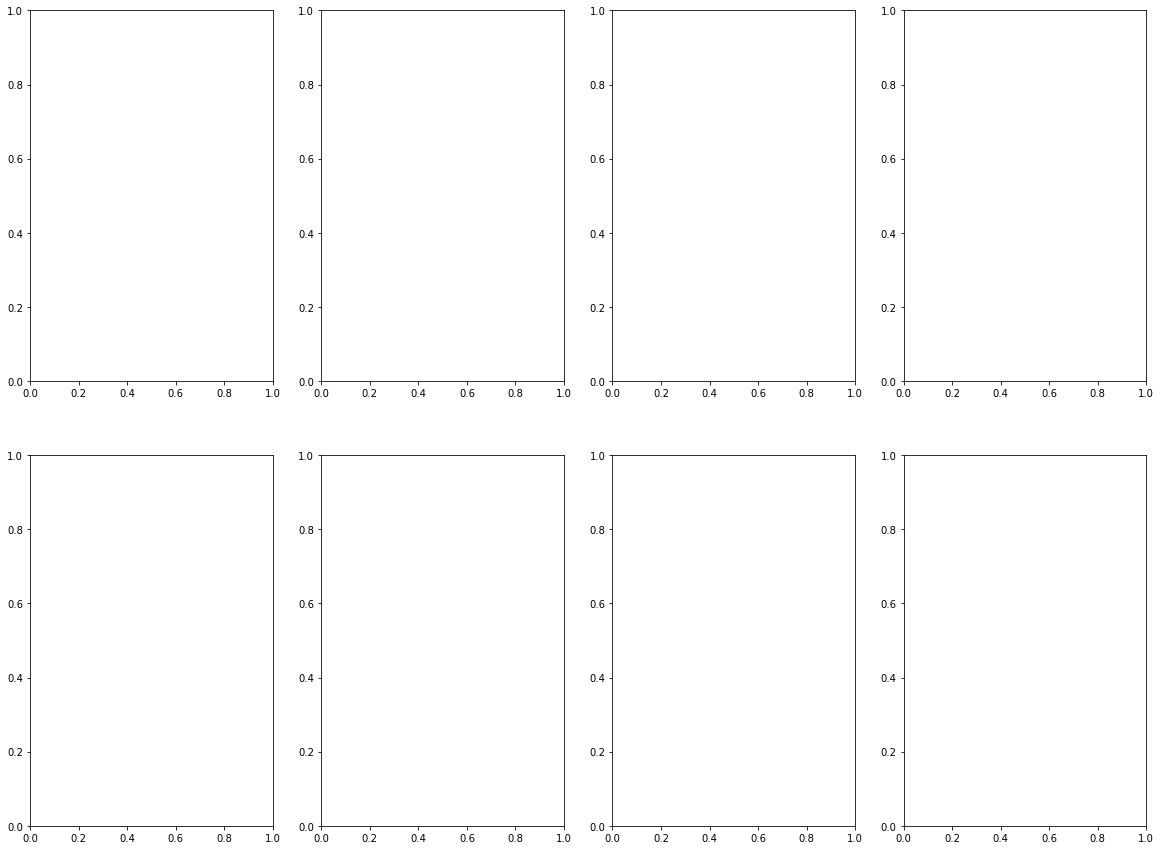

In [13]:
if initval.suffix == '.tif' and initval.sequence == 'time_trace':
    fig, axs = plt.subplots(2, 4, figsize=(20, 15))
    
    Guv_list = get_data_selections(round(expi))
    
    load_dirname_A20a = initval.mainpath_out + initval.subdir + "/A20a_tracked/"
    load_dirname_A20b = initval.mainpath_out + initval.subdir + "/A20b_processed/"
    
    guv_labels = []
    
    for this_guv in Guv_list:
        if this_guv.use_it == 1 and this_guv.movie_id in movie_to_use_list:
            movie_use_index = movie_to_use_list.index(this_guv.movie_id)
            guv_labels.append(this_guv.label)
            
            # Read data from CSV
            csv_source = Path(load_dirname_A20b + this_guv.label + "_all_data.csv")
            with open(csv_source) as g:
                reader = csv.DictReader(g, delimiter=";")
                data = list(reader)
            
            # Process and plot data
            plot_ax, area, roundness, major_minor = [], [], [], []
            c0_edge_mx, c1_edge_mx, c0_edge_sm, c1_edge_sm = [], [], [], []
            c1_std_sum_rel, ratio1 = [], []
            
            for fri, row in enumerate(data):
                # ... (data processing code)
                c1_mean_peaks=(float(row['c1_edge_mx']))
                c1_sum=float(row['c1_edge_sum'])
                okay_point=float(row['roundness'])>0 and float(row['R_minor'])>0 and c1_mean_peaks>400 and fri< this_guv.crop_it
                if okay_point:
                    #fetch work parameters:
                    axis_major=float(row['R_major'])
                    axis_minor=float(row['R_minor'])
                    c1_std_sum=float(row['c1_edge_sum_std'])
                    #c1_mean_peaks=(float(row['c1_edge_mx']))
                    c0_mean_peaks=(float(row['c0_edge_mx']))
                    #build plots:
                    if 1:
                        plot_ax.append(this_guv.dt*fri)
                        axlabel="time (s)"
                    if 0:
                        plot_ax.append(c1_sum)
                        axlabel="edge_sumI"
                    if 0:
                        plot_ax.append(c1_mean_peaks)
                        axlabel="edge_mx_I"    
                    area.append(float(row['area']))
                    roundness.append(float(row['roundness']))
                    major_minor.append(axis_major/axis_minor)
                    c0_edge_mx.append(c0_mean_peaks)
                    c1_edge_mx.append(c1_mean_peaks)
                    c0_edge_sm.append(float(row['c0_edge_sum']))
                    c1_edge_sm.append(c1_sum)
                    ratio1.append(float(row['c1_edge_sum'])/float(row['area']))
                    c1_std_sum_rel.append(c1_std_sum/c1_sum)
            
            simbol_color = movie_simbol_list[movie_use_index]
            sz = 2
            
            # Plot various metrics
            axs[0, 0].plot(plot_ax, area, 'o-', markersize=sz, color=simbol_color)
            axs[0, 0].set_ylabel("area")
            axs[0, 0].set_title("area")
            
            # ... (more plotting code for other metrics)
    
    plt.tight_layout()
    plt.show()

This completes the GUV image analysis pipeline. The notebook processes both single-frame and time-trace .tif files, collecting data and creating visualizations for various GUV metrics.